# What Drives the Price of a Used Car?

**OVERVIEW**

Identify which vehicle attributes most strongly predict price and quantify their impact, enabling a used car dealership to price inventory more accurately.

### CRISP-DM Framework
<img src = images/crisp.png width = 20%/>

This analysis follows the CRISP-DM process: Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment.

### Imports

In [1929]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')  # suppress sklearn convergence/deprecation noise

sns.set_theme(style='whitegrid', font_scale=1.2)
pd.set_option('display.max_columns', 50)

---
## 1. Business Understanding

A used car dealership wants to know which vehicle attributes drive price so they can extract maximum value from inventory.

**Data problem framing:** This is a supervised regression task. The target variable is `price`. Vehicle attributes (age, mileage, manufacturer, fuel type, transmission, title status, vehicle type, and drivetrain) are features to train and evaluate multiple regression models, and to interpret coefficients to identify which features have the largest positive and negative impact on price. The output will be a ranked list of price drivers to inform how the dealership prices its vehicles.

---
## 2. Data Understanding and 3. Data Preparation

In [1930]:
# Preview the data
df = pd.read_csv('data/vehicles.csv')
print('Shape:', df.shape)
df.head()

Shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [1931]:
# Inspect column data types to identify which columns need encoding or transformation.
df.dtypes

id                int64
region              str
price             int64
year            float64
manufacturer        str
model               str
condition           str
cylinders           str
fuel                str
odometer        float64
title_status        str
transmission        str
VIN                 str
drive               str
size                str
type                str
paint_color         str
state               str
dtype: object

In [1932]:
# Check NaNs across all columns. Columns with many missing values may need to be dropped.
missing = (df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
print('Missing values (%):')
print(missing)

Missing values (%):
size            71.8
cylinders       41.6
condition       40.8
VIN             37.7
drive           30.6
paint_color     30.5
type            21.8
manufacturer     4.1
title_status     1.9
model            1.2
odometer         1.0
fuel             0.7
transmission     0.6
year             0.3
id               0.0
region           0.0
price            0.0
state            0.0
dtype: float64


### Column candidates for removal (pass 1) and deduplication:

Remove:
* `id` is just an index. Remove this first then dedupe.
* `VIN` is an index and does not affect value; it also has 37.7% NaN values (missingness)
* `paint_color` doesn't affect value and has 30.5% NaN values

TBD:
* `region` seems like it will have extremely high cardinality and thus be a noisy signal
* More investigation is needed to determine if `size`, `cylinders`, `condition`, `drive`, and `type` are worth keeping despite their high NaN values.

In [1933]:
df = df.drop(columns=['id'])
df = df.drop_duplicates()
df = df.drop(columns=['VIN', 'paint_color'])
print('Shape:', df.shape)
df.head()

Shape: (370678, 15)


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Cardinality

In [1934]:
# Count unique values per string column to assess usability for modeling.
# OHE is only practical for low-cardinality columns (typically <50 unique values).
# High-cardinality columns cannot be one-hot encoded and must be dropped or clustered.

cardinality = df.select_dtypes(include='object').nunique().sort_values(ascending=False)
print('Unique values per string column:')
print(cardinality.to_string())

Unique values per string column:
model           29649
region            404
state              51
manufacturer       42
type               13
cylinders           8
condition           6
title_status        6
fuel                5
size                4
transmission        3
drive               3


### Column candidates for removal (pass 2):

* `model` has extremely high cardinality and is better described by other features (`manufacturer`, `type`, `size`)
* `region` is too cardinal. Sufficient geographic signal can likely be recovered from `state` if needed.

In [1935]:
# removing 'model' and 'region' columns
df = df.drop(columns=['model', 'region'])
print('Shape:', df.shape)
df.head()

Shape: (370678, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Analyzing column values

In [1936]:
for col in ['type', 'cylinders', 'condition', 'title_status', 'fuel', 'size', 'transmission', 'drive']:
    print(f'{col}: {sorted(df[col].dropna().unique())}')

type: ['SUV', 'bus', 'convertible', 'coupe', 'hatchback', 'mini-van', 'offroad', 'other', 'pickup', 'sedan', 'truck', 'van', 'wagon']
cylinders: ['10 cylinders', '12 cylinders', '3 cylinders', '4 cylinders', '5 cylinders', '6 cylinders', '8 cylinders', 'other']
condition: ['excellent', 'fair', 'good', 'like new', 'new', 'salvage']
title_status: ['clean', 'lien', 'missing', 'parts only', 'rebuilt', 'salvage']
fuel: ['diesel', 'electric', 'gas', 'hybrid', 'other']
size: ['compact', 'full-size', 'mid-size', 'sub-compact']
transmission: ['automatic', 'manual', 'other']
drive: ['4wd', 'fwd', 'rwd']


### Cylinders should be converted into an numerical value

In [1937]:
# This turned out to be an unnecessary step because 'cylinders' is later excluded from the model.
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)').astype(float)
print('Shape:', df.shape)
df.head()


Shape: (370678, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


### Row candidates for removal (pass 1)
* Remove rows where `condition` is `salvage` - dealerships won't buy these
* Remove rows where `title_status` is `missing`, `parts only`, or `salvage` - dealerships won't buy these
* Remove rows that are missing `year` or `odometer` (the client cannot value a car without either of these two things; both features have low NaN%)

In [1938]:
df = df[df['condition'] != 'salvage']
df = df[~df['title_status'].isin(['missing', 'parts only', 'salvage'])]
df = df.dropna(subset=['year', 'odometer'])
print('Shape:', df.shape)
df.head()

Shape: (361510, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
27,33590,2014.0,gmc,good,8.0,gas,57923.0,clean,other,NaN,NaN,pickup,al
28,22590,2010.0,chevrolet,good,8.0,gas,71229.0,clean,other,NaN,NaN,pickup,al
29,39590,2020.0,chevrolet,good,8.0,gas,19160.0,clean,other,NaN,NaN,pickup,al
30,30990,2017.0,toyota,good,8.0,gas,41124.0,clean,other,NaN,NaN,pickup,al
31,15000,2013.0,ford,excellent,6.0,gas,128000.0,clean,automatic,rwd,full-size,truck,al


### Visualizing and Cleaning Outliers

Box plots expose extreme values in the three numeric columns (`price`, `odometer`, `year`). Distributions are shown before and after removal to confirm the cleaning worked. Outlier bounds are computed statistically: log-IQR for `price` (right-skewed), raw IQR for `year` (approximately symmetric; the log transform is near-inert on values clustered around 2000), and a 99th-percentile cap (280K mi) for `odometer` where the log-IQR upper bound (875K mi) is physically implausible.

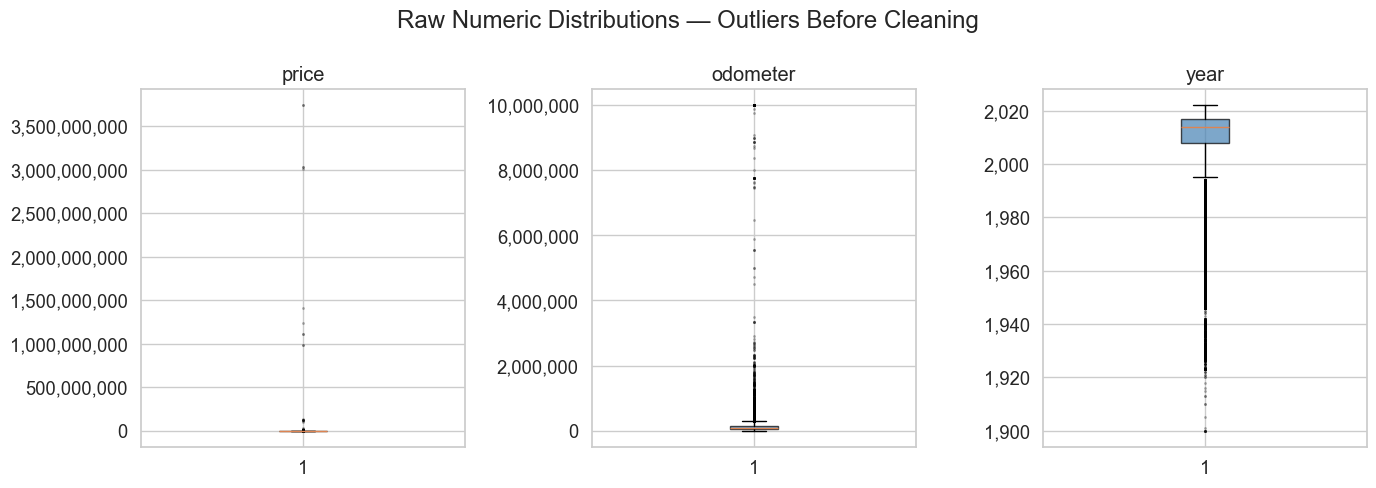

In [1939]:
# Visualize raw distributions of numeric columns before outlier removal.
# Box plot whiskers extend to Q1 - 1.5*IQR and Q3 + 1.5*IQR; dots beyond are statistical outliers.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['price', 'odometer', 'year']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Raw Numeric Distributions — Outliers Before Cleaning')
plt.tight_layout()
plt.show()


In [1940]:
# Remove outliers from price, odometer, and year using the previously stated logic.

def iqr_bounds_log(series):
    log_s = np.log(series[series > 0])
    q1, q3 = log_s.quantile(0.25), log_s.quantile(0.75)
    iqr = q3 - q1
    return np.exp(q1 - 1.5 * iqr), np.exp(q3 + 1.5 * iqr)

def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# price: log-IQR (right-skewed distribution)
lo, hi = iqr_bounds_log(df['price'].dropna())
df = df[(df['price'] >= lo) & (df['price'] <= hi)]
print(f'price: kept [{lo:,.0f} – {hi:,.0f}], rows remaining: {len(df):,}')

# year: raw IQR (approximately symmetric; log transform is near-inert on values clustered around 2000)
lo, hi = iqr_bounds(df['year'].dropna())
df = df[(df['year'] >= lo) & (df['year'] <= hi)]
print(f'year: kept [{lo:,.0f} – {hi:,.0f}], rows remaining: {len(df):,}')

# odometer: 99th-percentile cap (log-IQR upper bound of 875K mi is physically implausible)
df = df[(df['odometer'] >= 1) & (df['odometer'] <= 280_000)]
print(f'odometer: kept [1 – 280,000], rows remaining: {len(df):,}')

print('Shape:', df.shape)
df.head()

price: kept [1,040 – 201,838], rows remaining: 327,285
year: kept [1,994 – 2,030], rows remaining: 313,645
odometer: kept [1 – 280,000], rows remaining: 310,255
Shape: (310255, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
27,33590,2014.0,gmc,good,8.0,gas,57923.0,clean,other,NaN,NaN,pickup,al
28,22590,2010.0,chevrolet,good,8.0,gas,71229.0,clean,other,NaN,NaN,pickup,al
29,39590,2020.0,chevrolet,good,8.0,gas,19160.0,clean,other,NaN,NaN,pickup,al
30,30990,2017.0,toyota,good,8.0,gas,41124.0,clean,other,NaN,NaN,pickup,al
31,15000,2013.0,ford,excellent,6.0,gas,128000.0,clean,automatic,rwd,full-size,truck,al


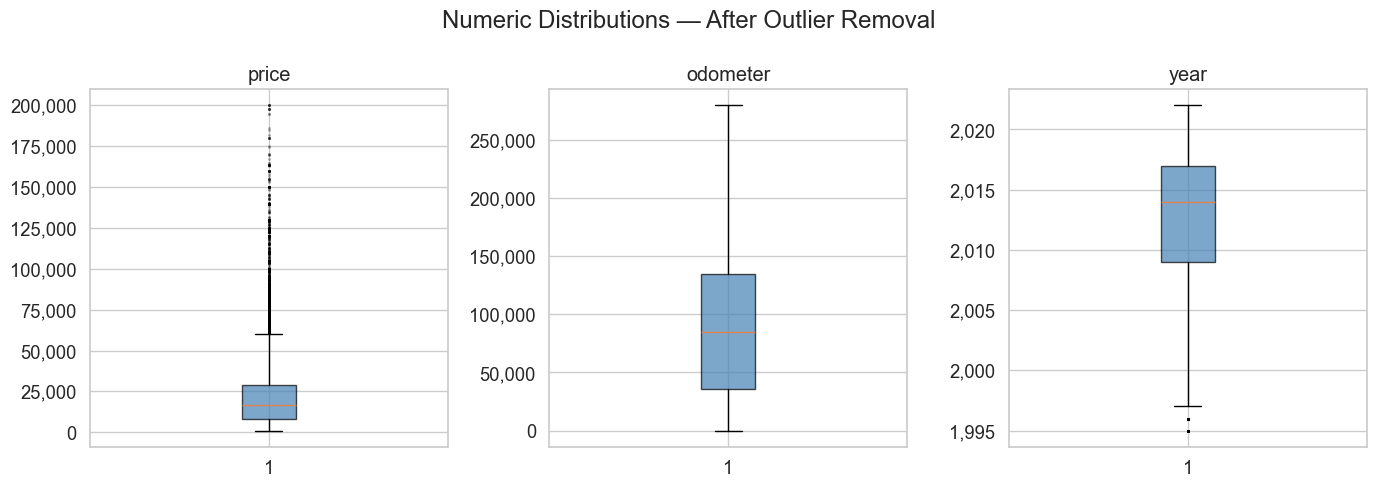

In [1941]:
# Confirm outlier removal worked, using the same plots as above.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, ['price', 'odometer', 'year']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Numeric Distributions — After Outlier Removal')
plt.tight_layout()
plt.show()


### Rare Category Detection

Low-frequency values in categorical columns can distort model coefficients: a manufacturer with 10 listings produces an unreliable coefficient that reflects noise rather than a real price signal. Any value appearing in less than 1% of rows is flagged.

In [1942]:
# Flag low-frequency categorical values that could produce unreliable model coefficients.
# A category appearing in <1% of rows gives the model very few examples to learn from, making its coefficient noisy rather than meaningful.

threshold = 0.01  # 1% frequency cutoff

# Identify all object (string) columns in the raw dataframe
text_cols = df.select_dtypes(include='object').columns.tolist()

# For each text column, collect values that appear in fewer than 1% of rows
rare_summary = {}
for col in text_cols:
    counts = df[col].value_counts(normalize=True)  # proportion of total rows
    rare = counts[counts < threshold]
    if len(rare) > 0:
        rare_summary[col] = rare

# Print a concise summary: top 5 rare values per column, suppressing full lists
for col, rare in rare_summary.items():
    print(f'\n--- {col}: {len(rare)} rare values ({rare.sum()*100:.1f}% of rows combined) ---')
    print(rare.head(5).to_string())
    if len(rare) > 5:
        print(f'  ... and {len(rare) - 5} more')


--- manufacturer: 17 rare values (5.6% of rows combined) ---
manufacturer
volvo         0.008737
mitsubishi    0.008524
mini          0.006454
jaguar        0.005603
rover         0.005350
  ... and 12 more

--- condition: 1 rare values (0.4% of rows combined) ---
condition
new    0.004039

--- fuel: 1 rare values (0.5% of rows combined) ---
fuel
electric    0.00476

--- title_status: 1 rare values (0.4% of rows combined) ---
title_status
lien    0.00434

--- type: 2 rare values (0.3% of rows combined) ---
type
offroad    0.001439
bus        0.001399

--- state: 20 rare values (10.5% of rows combined) ---
state
mo    0.009537
nm    0.009479
nv    0.007894
ar    0.007690
dc    0.007620
  ... and 15 more


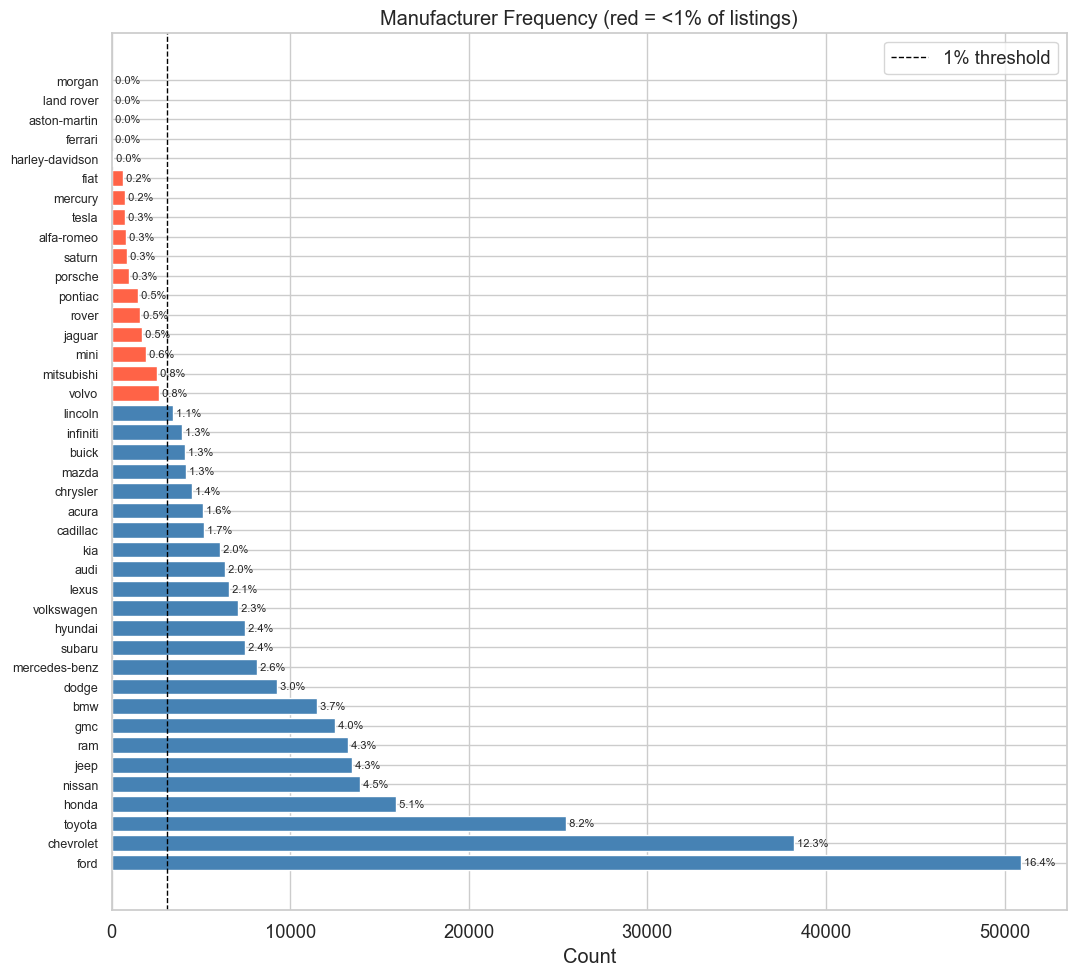

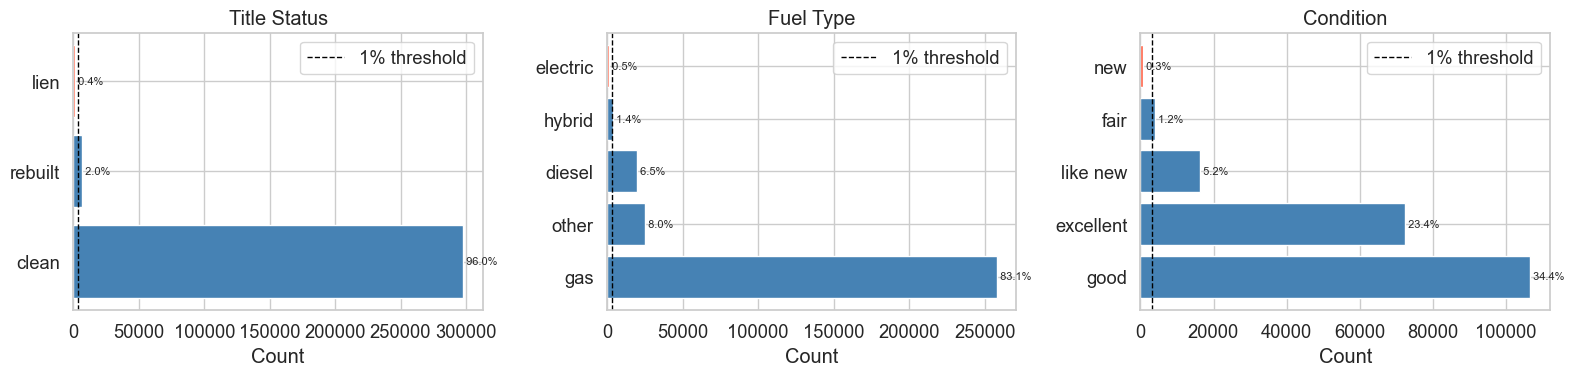

In [1943]:
# Visualize the frequency distribution of categorical features, highlighting values that fall below the 1% threshold defined above.
# Red bars = rare values whose coefficients would be unreliable in a regression model.

def freq_barh(ax, series, title):
    counts = series.value_counts()
    colors = ['tomato' if (v / len(df)) < threshold else 'steelblue' for v in counts.values]
    bars = ax.barh(counts.index, counts.values, color=colors)
    ax.axvline(len(df) * threshold, color='black', linestyle='--', linewidth=1, label='1% threshold')
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.legend()
    for bar, val in zip(bars, counts.values):
        pct = val / len(df) * 100
        ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
                f' {pct:.1f}%', va='center', ha='left', fontsize=8)

# Manufacturer: tall figure to accommodate ~40 labels without overlap
fig, ax = plt.subplots(figsize=(11, 10))
mfr_counts = df['manufacturer'].value_counts()
colors = ['tomato' if (v / len(df)) < threshold else 'steelblue' for v in mfr_counts.values]
bars = ax.barh(mfr_counts.index, mfr_counts.values, color=colors)
ax.axvline(len(df) * threshold, color='black', linestyle='--', linewidth=1, label='1% threshold')
ax.set_title('Manufacturer Frequency (red = <1% of listings)')
ax.set_xlabel('Count')
ax.tick_params(axis='y', labelsize=9)
ax.legend()
for bar, val in zip(bars, mfr_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2,
            f' {pct:.1f}%', va='center', ha='left', fontsize=8)
plt.tight_layout()
plt.show()

# Title status, fuel, condition: one row, short figure
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
freq_barh(axes[0], df['title_status'], 'Title Status')
freq_barh(axes[1], df['fuel'],         'Fuel Type')
freq_barh(axes[2], df['condition'],    'Condition')
plt.tight_layout()
plt.show()

### Rare Category Actions

Based on the frequency plots above:

- **Manufacturer:** 17 of 42 manufacturers fall below the 1% threshold. They are heterogeneous: some are low-volume luxury/sports brands (Porsche, Ferrari, Jaguar, Alfa-Romeo), some are simply less popular mainstream brands (Volvo, Mitsubishi, Mini), and some are discontinued (Saturn, Mercury, Pontiac). In Data Preparation, listings from the 5 nameplates below 0.1% are dropped entirely. They are not a coherent segment (Harley-Davidson makes motorcycles; Morgan had 1 listing; Ferrari, Aston-Martin, and Land Rover are exotic or niche market). Brands like Porsche, Tesla, and Volvo retain their own coefficients.
- **Title status:** `lien` is at 0.43%, below the 1% threshold. Rather than collapsing it, it is merged into `clean` in Data Preparation. Domain logic and post-modeling investigation (Section 5) both confirm it carries no independent price signal.
- **Fuel type:** `electric` is at 0.47%, just below threshold. It overlaps substantially with Tesla (the dominant electric brand in this dataset) but also includes other EVs (Leaf, Bolt, etc.). Retained as-is.
- **Condition:** Dropped entirely in Data Preparation due to high missingness (40.8%) and representativeness bias. Rare condition values are moot.
- **State:** 51 unique values, too high for OHE. Geographic pricing is out of scope; dropped in Data Preparation.

In [1944]:
# drop rare manufacturers

mfr_freq = df['manufacturer'].value_counts(normalize=True)
rare_mfrs = mfr_freq[mfr_freq < 0.001].index  # 0.001 = 0.1% of rows
df = df[~df['manufacturer'].isin(rare_mfrs)]

print(f'Dropped {len(rare_mfrs)} rare manufacturers: {list(rare_mfrs)}')
print(f'Rows remaining: {len(df):,}')

print('Shape:', df.shape)
df.head()


Dropped 5 rare manufacturers: ['harley-davidson', 'ferrari', 'aston-martin', 'land rover', 'morgan']
Rows remaining: 310,069
Shape: (310069, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
27,33590,2014.0,gmc,good,8.0,gas,57923.0,clean,other,NaN,NaN,pickup,al
28,22590,2010.0,chevrolet,good,8.0,gas,71229.0,clean,other,NaN,NaN,pickup,al
29,39590,2020.0,chevrolet,good,8.0,gas,19160.0,clean,other,NaN,NaN,pickup,al
30,30990,2017.0,toyota,good,8.0,gas,41124.0,clean,other,NaN,NaN,pickup,al
31,15000,2013.0,ford,excellent,6.0,gas,128000.0,clean,automatic,rwd,full-size,truck,al


### Title Status: Scoping the Dataset

`lien` will be merged into `clean` in Data Preparation: domain logic and post-modeling investigation (Section 5) both confirm it carries no independent price signal.

Three title categories were already excluded from `df` in Section 2 on business grounds: a dealership would not carry them:
- **`missing`**: no title on file; cannot be legally transferred in most states
- **`salvage`**: insurance write-off; avoided by most dealers, lenders, and floorplan financiers
- **`parts only`**: non-functioning vehicle; not retail inventory

**`rebuilt`** (previously salvage, subsequently repaired and re-inspected by the state) is legally titled and transferable. It stays.

The dataset at this point contains only `clean`, `lien`, and `rebuilt` title vehicles.

In [1945]:
# Merge 'lien' into 'clean'.
df['title_status'] = df['title_status'].replace({'lien': 'clean'})

print('Title status distribution after merging lien into clean:')
print(df['title_status'].value_counts())

print('Shape:', df.shape)
df.head()


Title status distribution after merging lien into clean:
title_status
clean      299082
rebuilt      6276
Name: count, dtype: int64
Shape: (310069, 13)


,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,state
27,33590,2014.0,gmc,good,8.0,gas,57923.0,clean,other,NaN,NaN,pickup,al
28,22590,2010.0,chevrolet,good,8.0,gas,71229.0,clean,other,NaN,NaN,pickup,al
29,39590,2020.0,chevrolet,good,8.0,gas,19160.0,clean,other,NaN,NaN,pickup,al
30,30990,2017.0,toyota,good,8.0,gas,41124.0,clean,other,NaN,NaN,pickup,al
31,15000,2013.0,ford,excellent,6.0,gas,128000.0,clean,automatic,rwd,full-size,truck,al


### Feature Inclusion Analysis: Quality vs. Coverage

Several columns have high missingness and require a decision: drop the column entirely, or keep it and drop the rows where it's blank. The columns in question: `condition` (40.8%), `cylinders` (41.6%), `type` (21.8%), `drive` (30.6%), and `size` (71.8%).

The risk of keeping a column: if the rows that happen to have it filled in are systematically different (older, cheaper, higher-mileage), the result is a smaller, biased dataset trained on a different population than it's predicting for.

In [1946]:
# Test whether requiring each optional column biases the dataset toward a non-representative subset of the market.
# If rows with a field filled in skew older/cheaper, adding that column introduces selection bias.

# Baseline: df with outliers removed; ensure core fields are present
df_rep = df.dropna(subset=['year','manufacturer','fuel','odometer','title_status','transmission'])

combos_rep = {
    'Baseline':             [],
    'type':                 ['type'],
    'drive':                ['drive'],
    'type+drive':           ['type','drive'],
    'condition':            ['condition'],
    'type+condition':       ['type','condition'],
    'drive+condition':      ['drive','condition'],
    'type+drive+condition': ['type','drive','condition'],
    'cylinders':            ['cylinders'],
    'cyl+type+drive':       ['cylinders','type','drive'],
    'size':                 ['size'],
    'size+type+drive':      ['size','type','drive'],
}

rows = []
for label, cols in combos_rep.items():
    sub = df_rep.dropna(subset=cols) if cols else df_rep
    rows.append({
        'Subset':    label,
        'Rows':      len(sub),
        '% Kept':    round(len(sub)/len(df_rep)*100, 1),
        'Med Price': int(sub['price'].median()),
        'Med Year':  int(sub['year'].median()),
        'Med Odo':   int(sub['odometer'].median()),
        'P25 Price': int(sub['price'].quantile(0.25)),
        'P75 Price': int(sub['price'].quantile(0.75)),
        '% 2015+':   round((sub['year'] >= 2015).mean() * 100, 1),
    })

rep_df = pd.DataFrame(rows).set_index('Subset')
print(rep_df.to_string())


                        Rows  % Kept  Med Price  Med Year  Med Odo  P25 Price  P75 Price  % 2015+
Subset                                                                                           
Baseline              293852   100.0      16990      2014    84679       8000      28990     44.3
type                  235021    80.0      18477      2014    77018       9000      29990     47.9
drive                 207110    70.5      16865      2014    87391       8499      28500     43.7
type+drive            185712    63.2      16991      2014    84935       8795      28590     44.8
condition             189771    64.6      16990      2014    79393       7980      28590     44.0
type+condition        167203    56.9      17990      2014    72750       8500      29590     46.7
drive+condition       143839    48.9      14995      2013    91027       7495      26500     39.2
type+drive+condition  130825    44.5      15590      2013    87535       7609      26990     40.8
cylinders           

**Findings:**

- **`type` and `drive` alone, and together, are safe to add.** Median price, year, odometer, and % 2015+ all remain within 2% of the baseline. These columns were filled in uniformly across the market.
- **`condition` alone drifts slightly:** median odometer drops and % 2015+ falls, suggesting condition was filled in more often for older listings.
- **`drive+condition` and `type+drive+condition` show meaningful bias:** median price drops ~$1,300–$2,000, % 2015+ falls to 39–41%. Dropped.
- **`cylinders` introduces moderate bias:** only 58.9% of rows retained, median price drops $2,000, % 2015+ falls to 37.7%. Adding it with type+drive (`cyl+type+drive`) retains only 46% of rows with further drift. Dropped.
- **`size` shows severe bias:** only 28.2% of rows retained, median price drops from $16,990 to $11,000, median year drops two years, % 2015+ falls from 44.3% to 28.9%. The rows where size is filled in represent a fundamentally different (cheaper, older) market segment. Dropped.
- **`type+drive` is the optimal addition:** 63.2% of rows retained, nearly identical to baseline on all representativeness metrics, and adds two meaningful price signals: vehicle segment and drivetrain.


**Data Preparation Decisions: Column and Row Strategy**

Based on the representativeness analysis above, the following decisions govern Section 3:
- `type` (21.8% missing): **keep column, drop rows**: requiring it retains 78.5% of data with negligible representativeness drift
- `drive` (30.6% missing): **keep column, drop rows**: requiring it alongside `type` retains 62.5% of data with negligible drift across all market metrics
- `size` (71.8% missing): **drop column**: 71.8% missing; keeping it would discard nearly three-quarters of rows
- `condition`, `cylinders` (~41% missing): **drop columns**: requiring them biases toward older inventory; condition is partially captured by age and mileage
- `state`: **drop column**: 51 unique values; geographic pricing is left for future work

After dropping columns, all remaining rows with any NaN, including rows where `type` or `drive` is blank, are removed, yielding the cleaned dataset used throughout the rest of the analysis.

In [1947]:
# Remove remaining columns that cannot be used as model features.

cols_to_drop = ['size', 'condition', 'cylinders', 'state']
df = df.drop(columns=cols_to_drop)
print('Shape:', df.shape)
df.head()


Shape: (310069, 9)


,price,year,manufacturer,fuel,odometer,title_status,transmission,drive,type
27,33590,2014.0,gmc,gas,57923.0,clean,other,NaN,pickup
28,22590,2010.0,chevrolet,gas,71229.0,clean,other,NaN,pickup
29,39590,2020.0,chevrolet,gas,19160.0,clean,other,NaN,pickup
30,30990,2017.0,toyota,gas,41124.0,clean,other,NaN,pickup
31,15000,2013.0,ford,gas,128000.0,clean,automatic,rwd,truck


In [1948]:
# Remove all rows with any remaining NaN values.
# Because type and drive were kept as columns (not dropped), this step also enforces that every row in the training set has both fields present.

df = df.dropna()
print('Shape:', df.shape)
df.head()


Shape: (185712, 9)


,price,year,manufacturer,fuel,odometer,title_status,transmission,drive,type
31,15000,2013.0,ford,gas,128000.0,clean,automatic,rwd,truck
32,27990,2012.0,gmc,gas,68696.0,clean,other,4wd,pickup
33,34590,2016.0,chevrolet,gas,29499.0,clean,other,4wd,pickup
34,35000,2019.0,toyota,gas,43000.0,clean,automatic,4wd,truck
35,29990,2016.0,chevrolet,gas,17302.0,clean,other,4wd,pickup


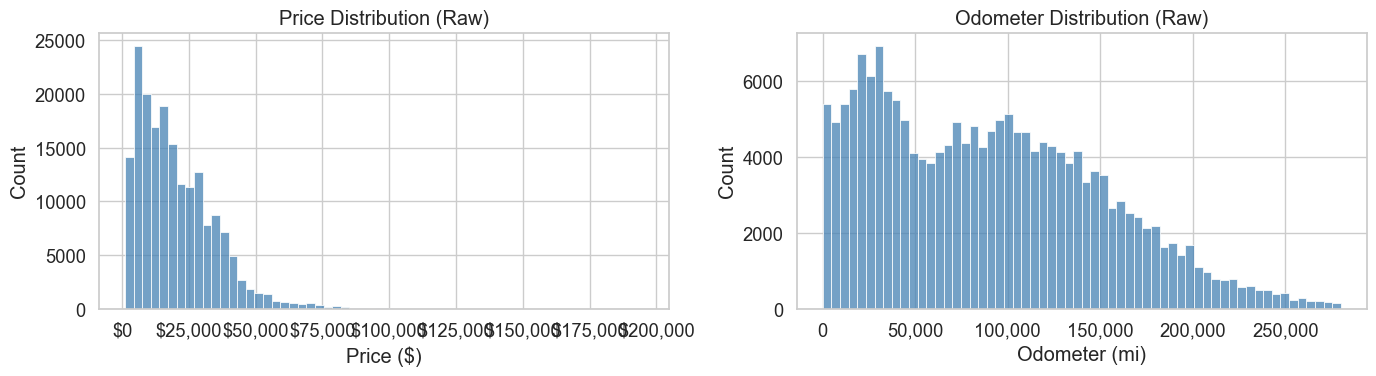

In [1949]:
# Raw distributions of price and odometer before log-transformation.
# Right skew in both motivates the log-transform applied in the next cell.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['price'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.histplot(df['odometer'], bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Odometer Distribution (Raw)')
axes[1].set_xlabel('Odometer (mi)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()


In [1950]:
# age: replaces year; added to df then year dropped
df['age'] = 2025 - df['year']
df = df.drop(columns=['year'])

# df_log: modeling dataframe with log-transformed numeric targets.
# log_price and log_odometer: raw distributions for both are right-skewed; log-transform produces an approximately normal distribution
df_log = df.drop(columns=['price', 'odometer']).copy()
df_log['log_price'] = np.log(df['price'])
df_log['log_odometer'] = np.log(df['odometer'] + 1)

print('df shape:', df.shape)
print('df_log shape:', df_log.shape)
df_log.head()


df shape: (185712, 9)
df_log shape: (185712, 9)


,manufacturer,fuel,title_status,transmission,drive,type,age,log_price,log_odometer
31,ford,gas,clean,automatic,rwd,truck,12.0,9.615805,11.759793
32,gmc,gas,clean,other,4wd,pickup,13.0,10.239603,11.137461
33,chevrolet,gas,clean,other,4wd,pickup,9.0,10.451320,10.292146
34,toyota,gas,clean,automatic,4wd,truck,6.0,10.463103,10.668979
35,chevrolet,gas,clean,other,4wd,pickup,9.0,10.308619,9.758635


### Cleaned Data Exploration

With outliers removed and features engineered, meaningful relationships between price and the predictors can now be explored.

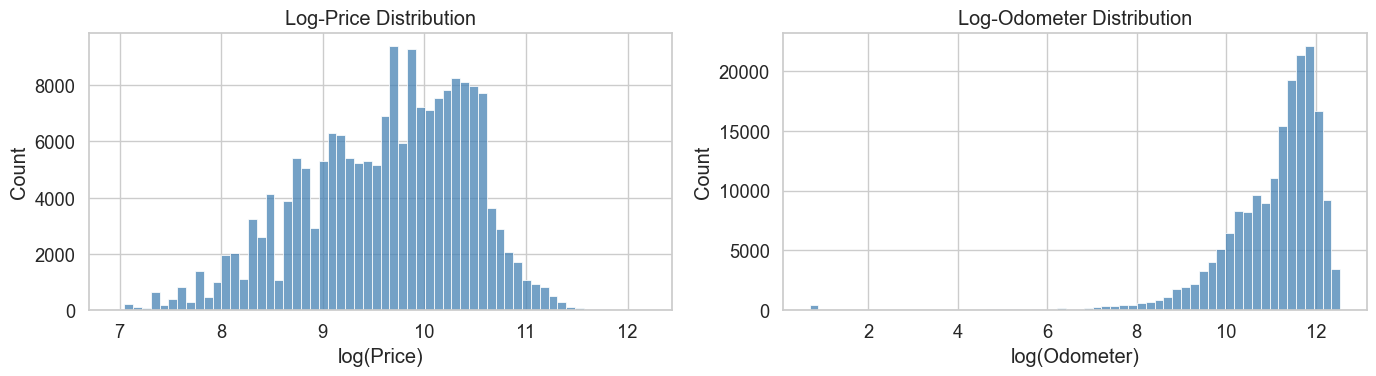

In [1951]:
# Log-transforming price and odometer produces roughly symmetric distributions
# suitable for linear regression; both were right-skewed in raw form.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df_log['log_price'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Log-Price Distribution')
axes[0].set_xlabel('log(Price)')
axes[0].set_ylabel('Count')

sns.histplot(df_log['log_odometer'], bins=60, ax=axes[1], color='steelblue')
axes[1].set_title('Log-Odometer Distribution')
axes[1].set_xlabel('log(Odometer)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


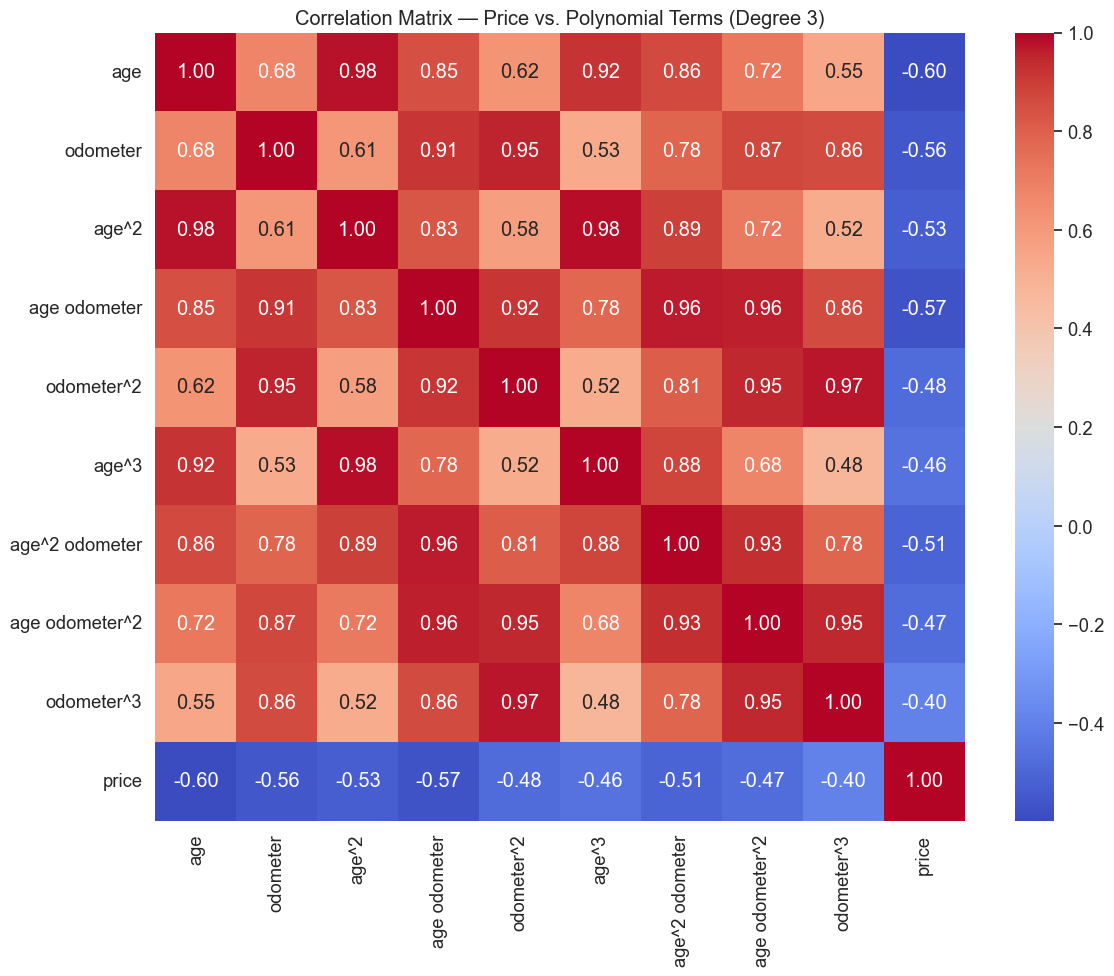

In [1952]:
# Explore how polynomial combinations of age and odometer correlate with price.

raw_df = pd.DataFrame({'age': df['age'], 'odometer': df['odometer']})

poly = PolynomialFeatures(degree=3, include_bias=False)
poly_arr = poly.fit_transform(raw_df)
poly_feat_names = poly.get_feature_names_out(['age', 'odometer'])

poly_df = pd.DataFrame(poly_arr, columns=poly_feat_names, index=df.index)
poly_df['price'] = df['price']

plt.figure(figsize=(12, 10))
sns.heatmap(poly_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix — Price vs. Polynomial Terms (Degree 3)')
plt.tight_layout()
plt.show()


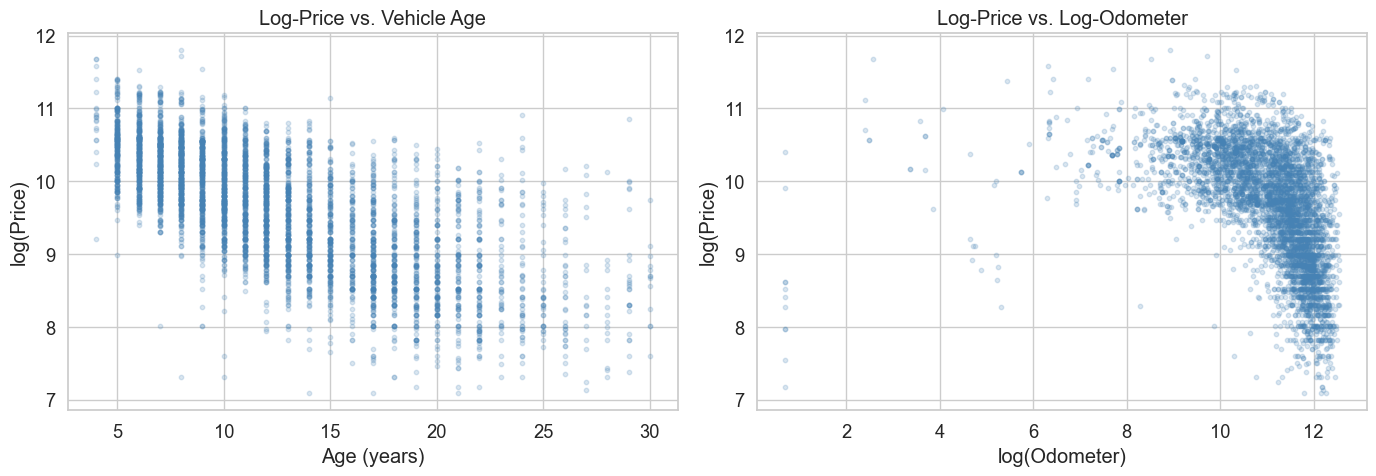

In [1953]:
# Visualize the relationship between log-price and age and log_odometer using a random 5,000-row sample

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df_log.sample(5000, random_state=42)  # subsample for plot speed

axes[0].scatter(sample['age'], sample['log_price'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Log-Price vs. Vehicle Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('log(Price)')

axes[1].scatter(sample['log_odometer'], sample['log_price'], alpha=0.2, s=10, color='steelblue')
axes[1].set_title('Log-Price vs. Log-Odometer')
axes[1].set_xlabel('log(Odometer)')
axes[1].set_ylabel('log(Price)')

plt.tight_layout()
plt.show()

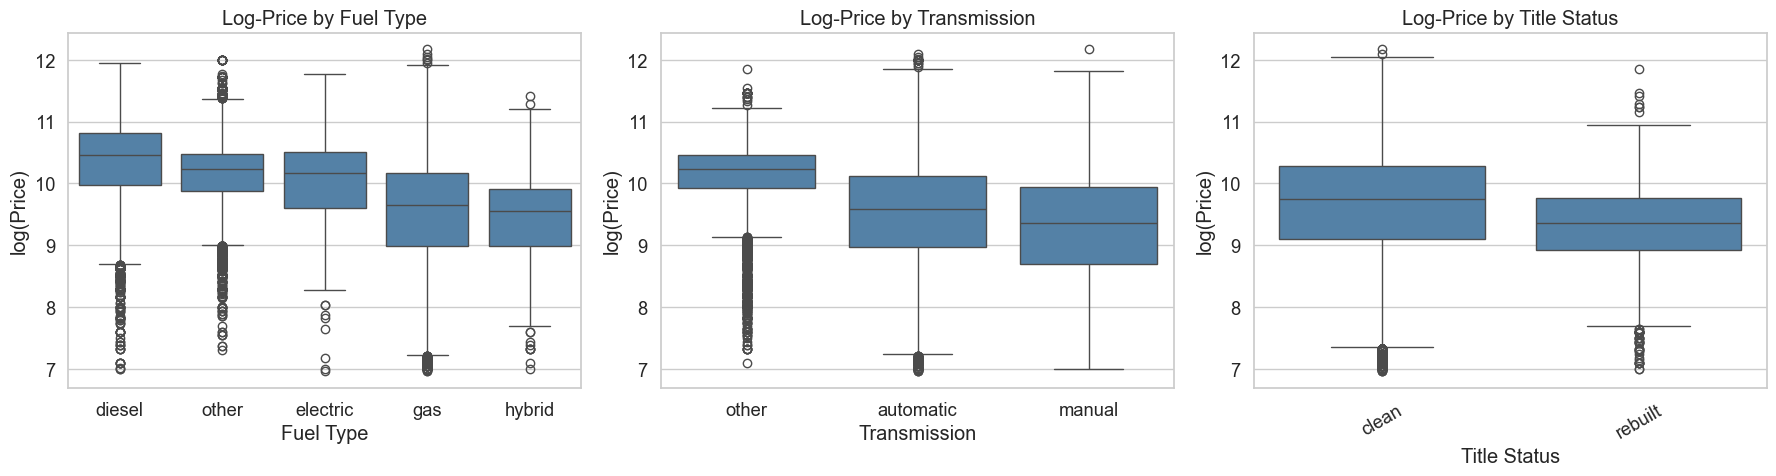

In [1954]:
# Visualizing price (as log-price) vs. key features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fuel type: diesel vs. gas vs. hybrid vs. electric
fuel_order = df_log.groupby('fuel')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_log, x='fuel', y='log_price', order=fuel_order, ax=axes[0], color='steelblue')
axes[0].set_title('Log-Price by Fuel Type')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('log(Price)')

# Transmission: automatic vs. manual vs. other
trans_order = df_log.groupby('transmission')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_log, x='transmission', y='log_price', order=trans_order, ax=axes[1], color='steelblue')
axes[1].set_title('Log-Price by Transmission')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('log(Price)')

# Title status: clean vs. rebuilt (salvage, missing, parts only were filtered in Section 2)
title_order = df_log.groupby('title_status')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_log, x='title_status', y='log_price', order=title_order, ax=axes[2], color='steelblue')
axes[2].set_title('Log-Price by Title Status')
axes[2].set_xlabel('Title Status')
axes[2].set_ylabel('log(Price)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

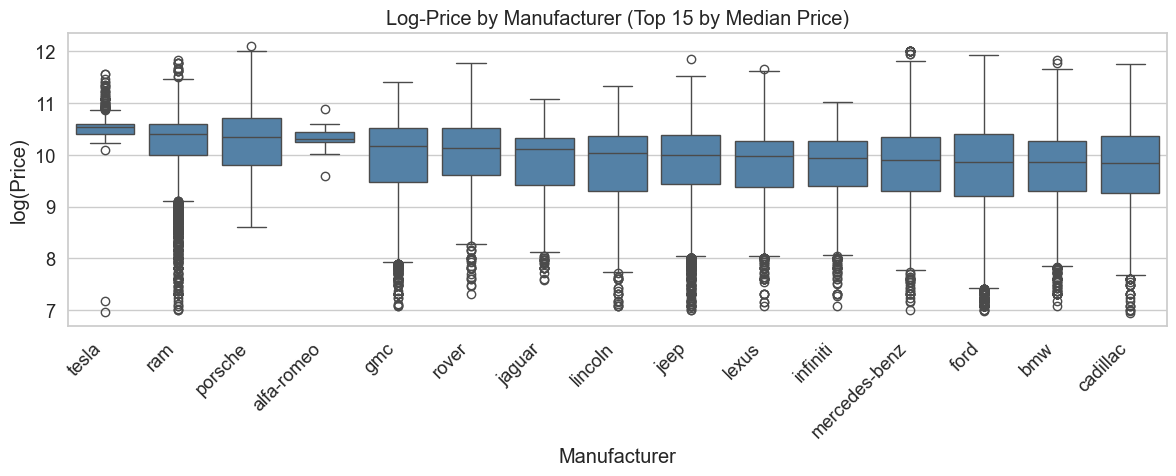

In [1955]:
# Visualizing price (as log-price) vs. manufacturer

top_mfr = df_log.groupby('manufacturer')['log_price'].median().sort_values(ascending=False).head(15).index
df_top_mfr = df_log[df_log['manufacturer'].isin(top_mfr)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_top_mfr, x='manufacturer', y='log_price',
            order=top_mfr, color='steelblue')
plt.title('Log-Price by Manufacturer (Top 15 by Median Price)')
plt.xlabel('Manufacturer')
plt.ylabel('log(Price)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Modeling

**Evaluation metric: RMSE on log-price.** Log-transformed price to address its strong right skew, making the regression target better-behaved. RMSE is used because it is in the same units as the target and penalizes large errors more heavily than MAE. All models are trained on the training set. The validation set is used for interim RMSE comparison only. Final performance is reported on the test set. A 60/20/20 split is used.

In [1956]:
# Split the dataset into train/validation/test sets using a 60/20/20 split.

X = df_log.drop(columns=['log_price'])
y = df_log['log_price']

# Step 1: hold out 20% as final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: split remaining 80% into train (75% of 80% = 60%) and val (25% of 80% = 20%)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)

print(f'Train:      {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')

Train:      111,426 rows (60%)
Validation: 37,143 rows (20%)
Test:       37,143 rows (20%)


### Scaling and Encoding: Preprocessing Setup

In [1957]:
# Feature groups - numeric vs. categorical
numeric_features = ['age', 'log_odometer']
categorical_features = ['manufacturer', 'fuel', 'title_status', 'transmission', 'type', 'drive']

# Base case: scale numerics, use OHE for categoricals
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
)

# Polynomial pipeline
numeric_poly_transformer = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Polynomial case; apply the pipeline and again use OHE for categoricals
poly_preprocessor = make_column_transformer(
    (numeric_poly_transformer, numeric_features),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
)

In [1958]:
# Define a RMSE function [same units as log(price), penalizes large errors more heavily than MAE]

def rmse(model, X, y):
    preds = model.predict(X)
    return np.sqrt(mean_squared_error(y, preds))

In [1959]:
# Fit preprocessors once on X_train, then transform all sets.

preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

poly_preprocessor.fit(X_train)
X_train_poly = poly_preprocessor.transform(X_train)
X_val_poly   = poly_preprocessor.transform(X_val)
X_test_poly  = poly_preprocessor.transform(X_test)

print(f'X_train_prep shape: {X_train_prep.shape}')
print(f'X_train_poly shape: {X_train_poly.shape}')

X_train_prep shape: (111426, 64)
X_train_poly shape: (111426, 67)


### Model 1: Linear Regression (Baseline)

In [1960]:
# Standard Linear Regression: baseline model, no regularization.

lr_model = LinearRegression()
lr_model.fit(X_train_prep, y_train)

lr_train_rmse = rmse(lr_model, X_train_prep, y_train)
lr_val_rmse   = rmse(lr_model, X_val_prep,   y_val)
lr_test_rmse  = rmse(lr_model, X_test_prep,  y_test)

print(f'Linear Regression — Train RMSE: {lr_train_rmse:.4f}')
print(f'Linear Regression — Val RMSE:   {lr_val_rmse:.4f}')
print(f'Linear Regression — Test RMSE:  {lr_test_rmse:.4f}')

Linear Regression — Train RMSE: 0.3971
Linear Regression — Val RMSE:   0.3968
Linear Regression — Test RMSE:  0.3940


### Model 2: Ridge Regression

In [1961]:
# RidgeCV selects the best alpha via 5-fold cross-validation over 100 log-spaced values.

best_ridge = RidgeCV(alphas=np.logspace(-2, 3, 100), cv=5)
best_ridge.fit(X_train_prep, y_train)

ridge_train_rmse = rmse(best_ridge, X_train_prep, y_train)
ridge_val_rmse   = rmse(best_ridge, X_val_prep,   y_val)
ridge_test_rmse  = rmse(best_ridge, X_test_prep,  y_test)

print(f'Best alpha: {best_ridge.alpha_:.4f}')
print(f'Ridge — Train RMSE: {ridge_train_rmse:.4f}')
print(f'Ridge — Val RMSE:   {ridge_val_rmse:.4f}')
print(f'Ridge — Test RMSE:  {ridge_test_rmse:.4f}')

Best alpha: 2.9836
Ridge — Train RMSE: 0.3971
Ridge — Val RMSE:   0.3968
Ridge — Test RMSE:  0.3940


### Model 3: Lasso Regression

In [1962]:
# LassoCV selects the best alpha via 5-fold cross-validation over 100 log-spaced values.
# max_iter=10000 prevents convergence warnings at small alpha values.

best_lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000)
best_lasso.fit(X_train_prep, y_train)

lasso_train_rmse = rmse(best_lasso, X_train_prep, y_train)
lasso_val_rmse   = rmse(best_lasso, X_val_prep,   y_val)
lasso_test_rmse  = rmse(best_lasso, X_test_prep,  y_test)

print(f'Best alpha: {best_lasso.alpha_:.6f}')
print(f'Lasso — Train RMSE: {lasso_train_rmse:.4f}')
print(f'Lasso — Val RMSE:   {lasso_val_rmse:.4f}')
print(f'Lasso — Test RMSE:  {lasso_test_rmse:.4f}')

Best alpha: 0.000100
Lasso — Train RMSE: 0.3972
Lasso — Val RMSE:   0.3969
Lasso — Test RMSE:  0.3940


### Model 4: Polynomial Ridge Regression

In [1963]:
# Add polynomial (degree-2) terms for the numeric features 'age' and 'log_odometer'
# RidgeCV selects the best alpha via 5-fold cross-validation over 100 log-spaced values.
# Wider alpha range than linear Ridge

best_poly = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5)
best_poly.fit(X_train_poly, y_train)

poly_train_rmse = rmse(best_poly, X_train_poly, y_train)
poly_val_rmse   = rmse(best_poly, X_val_poly,   y_val)
poly_test_rmse  = rmse(best_poly, X_test_poly,  y_test)

print(f'Best alpha: {best_poly.alpha_:.4f}')
print(f'Poly Ridge — Train RMSE: {poly_train_rmse:.4f}')
print(f'Poly Ridge — Val RMSE:   {poly_val_rmse:.4f}')
print(f'Poly Ridge — Test RMSE:  {poly_test_rmse:.4f}')

Best alpha: 2.4771
Poly Ridge — Train RMSE: 0.3715
Poly Ridge — Val RMSE:   0.3695
Poly Ridge — Test RMSE:  0.3684


In [1964]:
# Summarize all four models in a single comparison table.
# Val RMSE was used to select the model (test set never touched during tuning).
# Test RMSE and Test R-squared are the final unbiased performance estimates.

def r2(model, X, y):
    return r2_score(y, model.predict(X))

results = pd.DataFrame({
    'Model':       ['Linear Regression', 'Ridge', 'Lasso', 'Polynomial Ridge'],
    'Train RMSE':  [lr_train_rmse,   ridge_train_rmse,  lasso_train_rmse,  poly_train_rmse],
    'Val RMSE':    [lr_val_rmse,     ridge_val_rmse,    lasso_val_rmse,    poly_val_rmse],
    'Test RMSE':   [lr_test_rmse,    ridge_test_rmse,   lasso_test_rmse,   poly_test_rmse],
    'Test R^2':    [r2(lr_model,   X_test_prep, y_test),   # linear baseline
                    r2(best_ridge, X_test_prep, y_test),   # RidgeCV
                    r2(best_lasso, X_test_prep, y_test),   # LassoCV
                    r2(best_poly,  X_test_poly, y_test)]   # Polynomial RidgeCV (selected)
})
print(results.to_string(index=False))

            Model  Train RMSE  Val RMSE  Test RMSE  Test R^2
Linear Regression    0.397070  0.396788   0.393956  0.761411
            Ridge    0.397071  0.396791   0.393955  0.761411
            Lasso    0.397162  0.396898   0.393983  0.761378
 Polynomial Ridge    0.371470  0.369535   0.368417  0.791342


---
## 5. Evaluation

**Polynomial Ridge is the best model.** It achieves the lowest train, validation, and test RMSE and highest R-squared of the four models (see comparison table above), confirming a nonlinear relationship between age/mileage and price: the depreciation penalty accelerates at the extremes.

**Interpreting RMSE on log-price:** The model predicts log(price), not price directly. This means that the error on price could be larger than the error on log(price). The model is best used for identifying *directional* price drivers rather than producing precise dollar estimates.

**Coefficients are reported from the Polynomial Ridge model** (the deployed model). The OHE categorical features (manufacturer, fuel, title status, etc.) each carry a single coefficient and are directly interpretable. The numeric polynomial terms (age, age-squared, age times log-odometer, log-odometer-squared) capture the depreciation curve as a group and are reported separately.

In [1965]:
# Extract and rank feature coefficients from the Polynomial Ridge model (the deployed model).
# OHE categorical features each carry a single interpretable coefficient.
# Numeric polynomial terms capture the depreciation curve as a group, reported separately.

# Numeric polynomial feature names from the fitted PolynomialFeatures step
poly_step = poly_preprocessor.transformers_[0][1].named_steps['poly']
numeric_poly_names = poly_step.get_feature_names_out(['age', 'log_odometer']).tolist()

# OHE feature names from the fitted OHE step inside poly_preprocessor
ohe = poly_preprocessor.transformers_[1][1]
ohe_features_poly = ohe.get_feature_names_out(categorical_features).tolist()

all_features_poly = numeric_poly_names + ohe_features_poly

coef_df = pd.DataFrame({
    'feature':     all_features_poly,
    'coefficient': best_poly.coef_
})

# Split into interpretable (OHE) and numeric polynomial terms
ohe_coef_df      = coef_df[coef_df['feature'].isin(ohe_features_poly)].sort_values('coefficient', ascending=False).reset_index(drop=True)
poly_num_coef_df = coef_df[coef_df['feature'].isin(numeric_poly_names)].reset_index(drop=True)

print('Categorical feature coefficients (fully interpretable):')
display(ohe_coef_df)

print('Numeric polynomial terms (interpret as a group, not individually):')
display(poly_num_coef_df)

Categorical feature coefficients (fully interpretable):


,feature,coefficient
0,manufacturer_porsche,0.619799
1,manufacturer_tesla,0.509426
2,fuel_diesel,0.425042
3,manufacturer_lexus,0.416723
4,type_offroad,0.282041
...,...,...
57,type_hatchback,-0.311836
58,manufacturer_mercury,-0.315402
59,manufacturer_mitsubishi,-0.323880
60,manufacturer_saturn,-0.342865


Numeric polynomial terms (interpret as a group, not individually):


,feature,coefficient
0,age,-0.158397
1,log_odometer,0.729197
2,age^2,0.096497
3,age log_odometer,-0.418987
4,log_odometer^2,-0.814953


In [1966]:
# Compute percentage price impact for key categorical features from the Polynomial Ridge coefficients.
# Numeric polynomial terms (age, age^2, etc.) are excluded: their effect is not single-term.
# On the log-price scale: pct_impact = (e^coef - 1) * 100

import math

key_features = [
    'manufacturer_porsche', 'manufacturer_tesla', 'fuel_diesel',
    'type_convertible', 'type_truck', 'type_pickup',
    'drive_fwd', 'type_sedan', 'type_hatchback',
    'manufacturer_saturn', 'manufacturer_fiat'
]

impacts = (
    ohe_coef_df[ohe_coef_df['feature'].isin(key_features)]
    .set_index('feature')
    .reindex([f for f in key_features if f in ohe_coef_df['feature'].values])
    .assign(pct_impact=lambda df: df['coefficient'].apply(lambda c: (math.exp(c) - 1) * 100))
    [['coefficient', 'pct_impact']]
)
impacts.columns = ['Coefficient', 'Price Impact (%)']
impacts['Price Impact (%)'] = impacts['Price Impact (%)'].map(lambda x: f'{x:+.0f}%')
impacts['Coefficient'] = impacts['Coefficient'].map(lambda x: f'{x:+.3f}')
print(impacts.to_string())

                     Coefficient Price Impact (%)
feature                                          
manufacturer_porsche      +0.620             +86%
manufacturer_tesla        +0.509             +66%
fuel_diesel               +0.425             +53%
type_convertible          +0.138             +15%
type_truck                +0.243             +27%
type_pickup               +0.209             +23%
drive_fwd                 -0.215             -19%
type_sedan                -0.290             -25%
type_hatchback            -0.312             -27%
manufacturer_saturn       -0.343             -29%
manufacturer_fiat         -0.369             -31%


**Coefficient interpretation:** Because the target is log-price, each coefficient approximates the percentage change in price associated with that feature, all else equal. Percentage impacts are computed above as (e^coefficient - 1). Only categorical features are shown; age and odometer are captured jointly by the polynomial terms and cannot be summarized by a single percentage.

- **Manufacturer is the dominant signal.** Porsche and Tesla carry the largest premiums among individually retained brands.
- **Vehicle type adds meaningful signal.** Pickup trucks and convertibles command premiums; sedans and hatchbacks carry discounts. Trucks hold value well; economy sedans compete on price.
- **Drivetrain matters.** Front-wheel drive is discounted relative to 4WD and RWD, consistent with buyer preference for trucks and SUVs with 4WD capability.
- **Diesel fuel commands a substantial premium** relative to gas; this is likely a niche effect.
- **Title status.** Intuitively, a `rebuilt` title carries a discount relative to `clean`.
- **Age and mileage** effects are captured jointly by the polynomial terms, which allow the depreciation penalty to accelerate nonlinearly at extremes.

---
## 6. Deployment: Findings for the Dealership

### Approach

This analysis examined over 185,000 used car listings and built four regression models: Linear Regression, Ridge, Lasso, and Polynomial Ridge, to predict price from vehicle attributes including age, mileage, manufacturer, fuel type, transmission, title status, vehicle type, and drivetrain. The dataset was scoped to vehicles a dealership would actually carry: clean, lien (merged into clean), and rebuilt titles only. Models were trained on 60% of the data, tuned on a 20% validation set, and evaluated on a final 20% blind test set. Polynomial Ridge was the best-performing model (see Section 5). Coefficients from the Polynomial Ridge model were used to rank and interpret price drivers.

### What Drives Price Up

1. **Manufacturer brand** is the single strongest price driver. Porsche and Tesla command the largest premiums among individually modeled brands.
2. **Vehicle type.** Pickup trucks and convertibles command premiums relative to the average vehicle. Demand for trucks is sustained and inventory turns faster.
3. **Diesel fuel** commands a substantial price premium over comparable gas vehicles, likely due to niche market effects.
4. **Clean title** adds meaningful value relative to rebuilt. Title status is among the most predictive and easily verified features.
5. **Lower mileage and newer model year** consistently increase price: these are the most controllable pricing levers.

### What Drives Price Down

1. **Rebuilt title** carries a measurable discount relative to clean. The model quantifies this discount in price terms.
2. **Missing, salvage, and parts-only titles** fall outside the scope of this model and were excluded from training data: missing titles can't be transferred, salvage titles are avoided by lenders and floorplan financiers, and parts-only vehicles aren't functioning retail inventory.
3. **Discontinued brands**, Saturn and Fiat in particular, carry large price penalties. Buyers discount them for long-term parts availability concerns.
4. **Front-wheel drive** prices below 4WD and RWD. Buyer preference skews toward trucks and SUVs with 4WD capability.
5. **Economy vehicle types** (sedans and hatchbacks) intuitively price below the average.
6. **High mileage and vehicle age** are consistent price depressors across all segments, with the penalty accelerating nonlinearly at extremes.

### Next Steps

- **Incorporate geographic pricing**: prices vary meaningfully by state and region, which this model does not currently capture.
- **Re-introduce `condition`**, dropped due to dataset bias risk (see Feature Inclusion Analysis), but is likely an important predictor. A richer or more consistently filled dataset could recover it.
- **Build a pricing tool** the dealership can use to estimate resale value for any vehicle in their inventory (below).

### Price Prediction Tool

The function below accepts raw vehicle attributes and returns a predicted price in dollars. Inputs are passed through the fitted `poly_preprocessor` and `best_poly`; no refitting occurs. R-squared on the log-price scale is unchanged; the function simply exponentiates the model's output.

R-squared on the actual price scale is also reported. It is typically lower than on the log-price scale because errors on expensive vehicles are amplified when transformed back.

In [1967]:
def predict_price(manufacturer, fuel, title_status, transmission, vehicle_type, drive, age, odometer):
    """
    Predict the price of a used vehicle using the fitted Polynomial Ridge model.

    Parameters
    ----------
    manufacturer  : str   e.g. 'ford', 'toyota'
    fuel          : str   'gas', 'diesel', 'hybrid', 'electric', 'other'
    title_status  : str   'clean', 'rebuilt'
    transmission  : str   'automatic', 'manual', 'other'
    vehicle_type  : str   'sedan', 'truck', 'pickup', 'SUV', 'convertible', etc.
    drive         : str   '4wd', 'fwd', 'rwd'
    age           : int   years since model year (e.g. 2025 - model_year)
    odometer      : int   mileage in miles
    """
    input_df = pd.DataFrame({
        'manufacturer': [manufacturer],
        'fuel':         [fuel],
        'title_status': [title_status],
        'transmission': [transmission],
        'type':         [vehicle_type],
        'drive':        [drive],
        'age':          [float(age)],
        'log_odometer': [np.log(odometer + 1)]
    })

    input_poly = poly_preprocessor.transform(input_df)
    log_price  = best_poly.predict(input_poly)[0]
    return np.exp(log_price)


# R-squared on actual price scale
y_test_price  = np.exp(y_test)
y_pred_price  = np.exp(best_poly.predict(X_test_poly))
r2_price_scale = r2_score(y_test_price, y_pred_price)

print(f'Test R-squared (log-price scale): {r2_score(y_test, best_poly.predict(X_test_poly)):.4f}')
print(f'Test R-squared (price scale):     {r2_price_scale:.4f}')
print()

# Example predictions
examples = [
    ('ford',   'gas',    'clean',   'automatic', 'truck',     '4wd', 5,  50_000),
    ('toyota', 'gas',    'clean',   'automatic', 'sedan',     'fwd', 3,  30_000),
    ('tesla',  'electric','clean',  'automatic', 'sedan',     'rwd', 2,  20_000),
    ('ford',   'diesel', 'clean',   'automatic', 'pickup',    '4wd', 4,  60_000),
    ('saturn', 'gas',    'rebuilt', 'automatic', 'sedan',     'fwd', 12, 120_000),
]

print(f'{"Manufacturer":<14} {"Type":<10} {"Drive":<6} {"Fuel":<10} {"Title":<9} {"Age":>4} {"Odometer":>10}  {"Predicted Price":>15}')
print('-' * 85)
for mfr, fuel, title, trans, vtype, drive, age, odo in examples:
    price = predict_price(mfr, fuel, title, trans, vtype, drive, age, odo)
    print(f'{mfr:<14} {vtype:<10} {drive:<6} {fuel:<10} {title:<9} {age:>4} {odo:>10,}  ${price:>14,.0f}')

Test R-squared (log-price scale): 0.7913
Test R-squared (price scale):     0.7097

Manufacturer   Type       Drive  Fuel       Title      Age   Odometer  Predicted Price
-------------------------------------------------------------------------------------
ford           truck      4wd    gas        clean        5     50,000  $        44,358
toyota         sedan      fwd    gas        clean        3     30,000  $        29,767
tesla          sedan      rwd    electric   clean        2     20,000  $        69,127
ford           pickup     4wd    diesel     clean        4     60,000  $        79,637
saturn         sedan      fwd    gas        rebuilt     12    120,000  $         4,763


---
## 7. Model Limitations and the Problem with Brand Coefficients

The model includes both `manufacturer` (via OHE) and `age` as features, so in theory the Tesla coefficient represents the brand premium holding age constant, which is the intended interpretation of the regression coefficients.

In practice, there are two reasons this is imperfect:

* **Collinearity.** Teslas in this dataset are concentrated in a narrow age range; the brand did not produce volume until the mid-2010s. When a manufacturer OHE column and `age` are correlated, the model has less independent variation to cleanly separate the two effects. Ridge regularization helps stabilize this but does not eliminate it. Some of the Tesla premium may be partially unexplained age effect bleeding into the brand coefficient.

* **Single depreciation slope.** The model applies one global `age` slope to all manufacturers. If Tesla's and other EV depreciation curves are shaped differently from the fleet average, which is plausible given software updates, battery range improvements, and changing demand, the model cannot capture that. The deviation between Tesla's actual depreciation curve and the average gets absorbed into the brand coefficient.

The Tesla coefficient is a reasonable signal that the brand commands a real premium, but the magnitude is probably slightly inflated. The same logic applies in the other direction to discontinued brands like Saturn: older age distribution means some of the brand discount may reflect age rather than true brand penalty.

The clean fix would be a manufacturer x age interaction term, but that adds significant model complexity.